Device: cpu  |  Mode: BOTH

  Loading DEAP 6-Class Data
  [V-H] Valence_PR_2classes/HV: 4,720 images
  [V-L] Valence_PR_2classes/LV: 400 images
  [A-H] Arousal_PR_2classes/HA: 2,880 images
  [A-L] Arousal_PR_2classes/LA: 2,250 images
  [D-H] Dominance_PR_2classes/HD: 4,160 images
  [D-L] Dominance_PR_2classes/LD: 970 images

  Total: 15,380 | Classes: 6 | Imbalance: 11.8x

  Train: 12,304  Test: 3,076
  Extracting train features... 211s
  Extracting test  features... 57s

  Running 5-fold cross-validation... done in 279s
  CV: [0.402 0.414 0.408 0.419 0.41 ]  Mean=0.4107 ± 0.0057
  Fitting final SVM... done in 125s

  ─────────────────────────────────────────────
  Accuracy : 0.3956
  Precision: 0.3898
  Recall   : 0.3956
  AUC-ROC  : 0.8782
  CV Mean  : 0.4107
  ─────────────────────────────────────────────
              precision    recall  f1-score   support

         V-H       0.93      0.94      0.94       944
         V-L       0.23      0.21      0.22        80
         A-H     

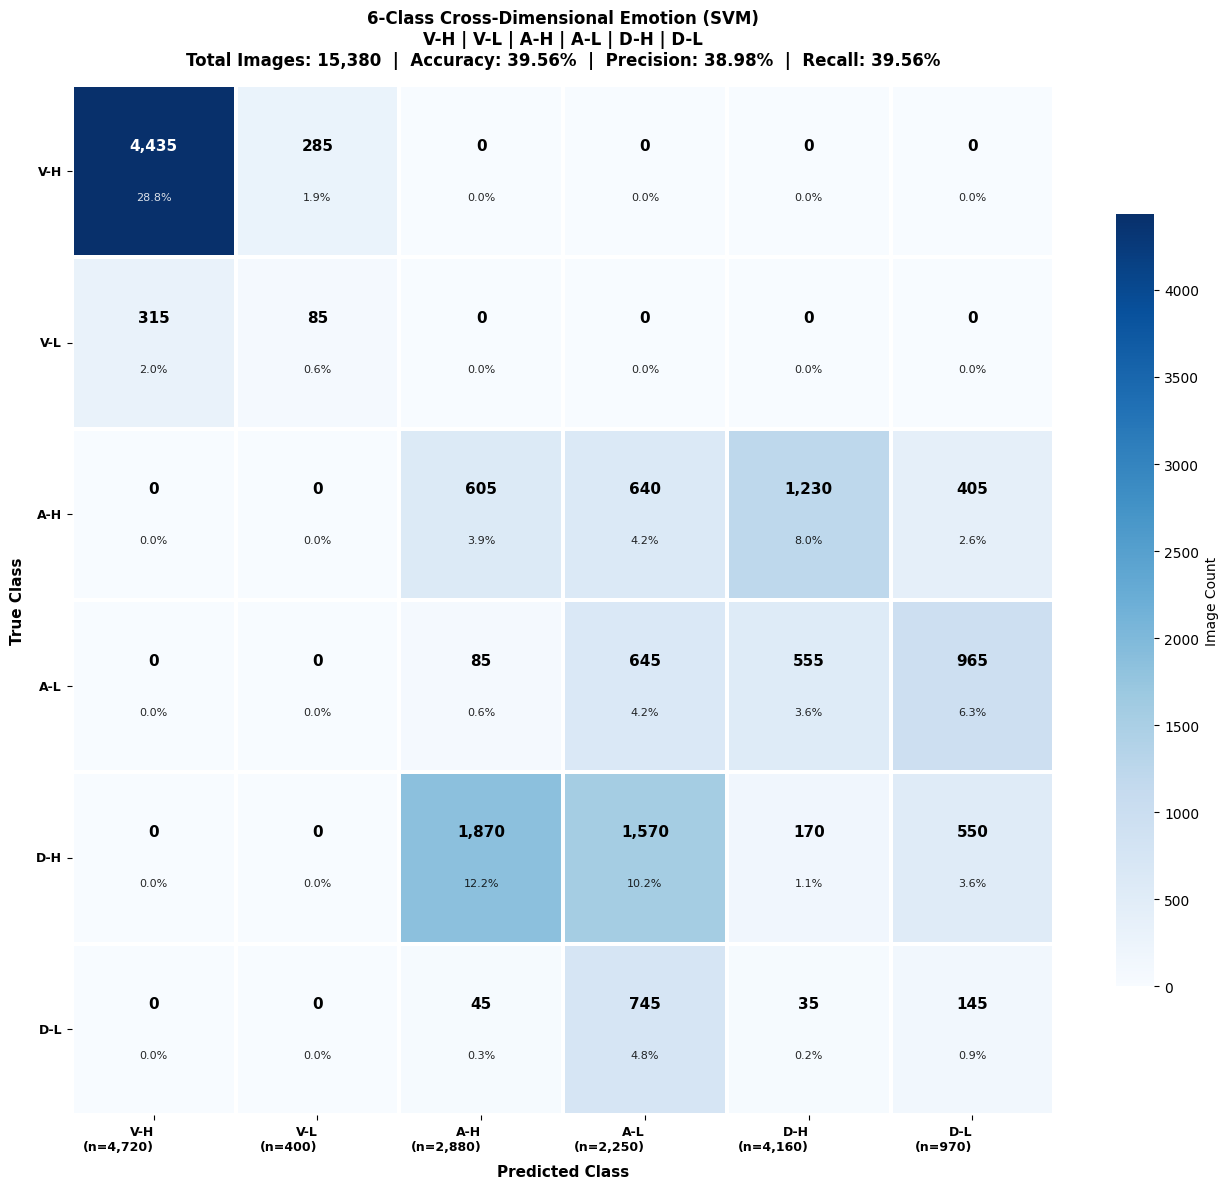

  Saved: cm_deap_6x6_svm.png

  Loading DREAMER 9-Class Data
     amusement:   46 images
         anger:   46 images
      calmness:   46 images
       disgust:   46 images
    excitement:   46 images
          fear:   46 images
     happiness:   46 images
       sadness:   46 images
      surprise:   46 images

  Total: 414 | Classes: 9 | Imbalance: 1.0x

  Original — Train: 331  Test: 83
  After aug (20x) — Train: 6951  Test: 83
  Extracting train features... 123s  shape=(6951, 512)
  Extracting test  features... 2s  shape=(83, 512)

  Running 5-fold cross-validation... done in 119s
  CV: [0.308 0.309 0.296 0.297 0.289]  Mean=0.2998 ± 0.0074
  Fitting final SVM... done in 49s

  ─────────────────────────────────────────────
  Accuracy : 0.0843
  Precision: 0.0725
  Recall   : 0.0843
  AUC-ROC  : 0.4731
  CV Mean  : 0.2998
  ─────────────────────────────────────────────
              precision    recall  f1-score   support

   amusement       0.17      0.22      0.19         9
       

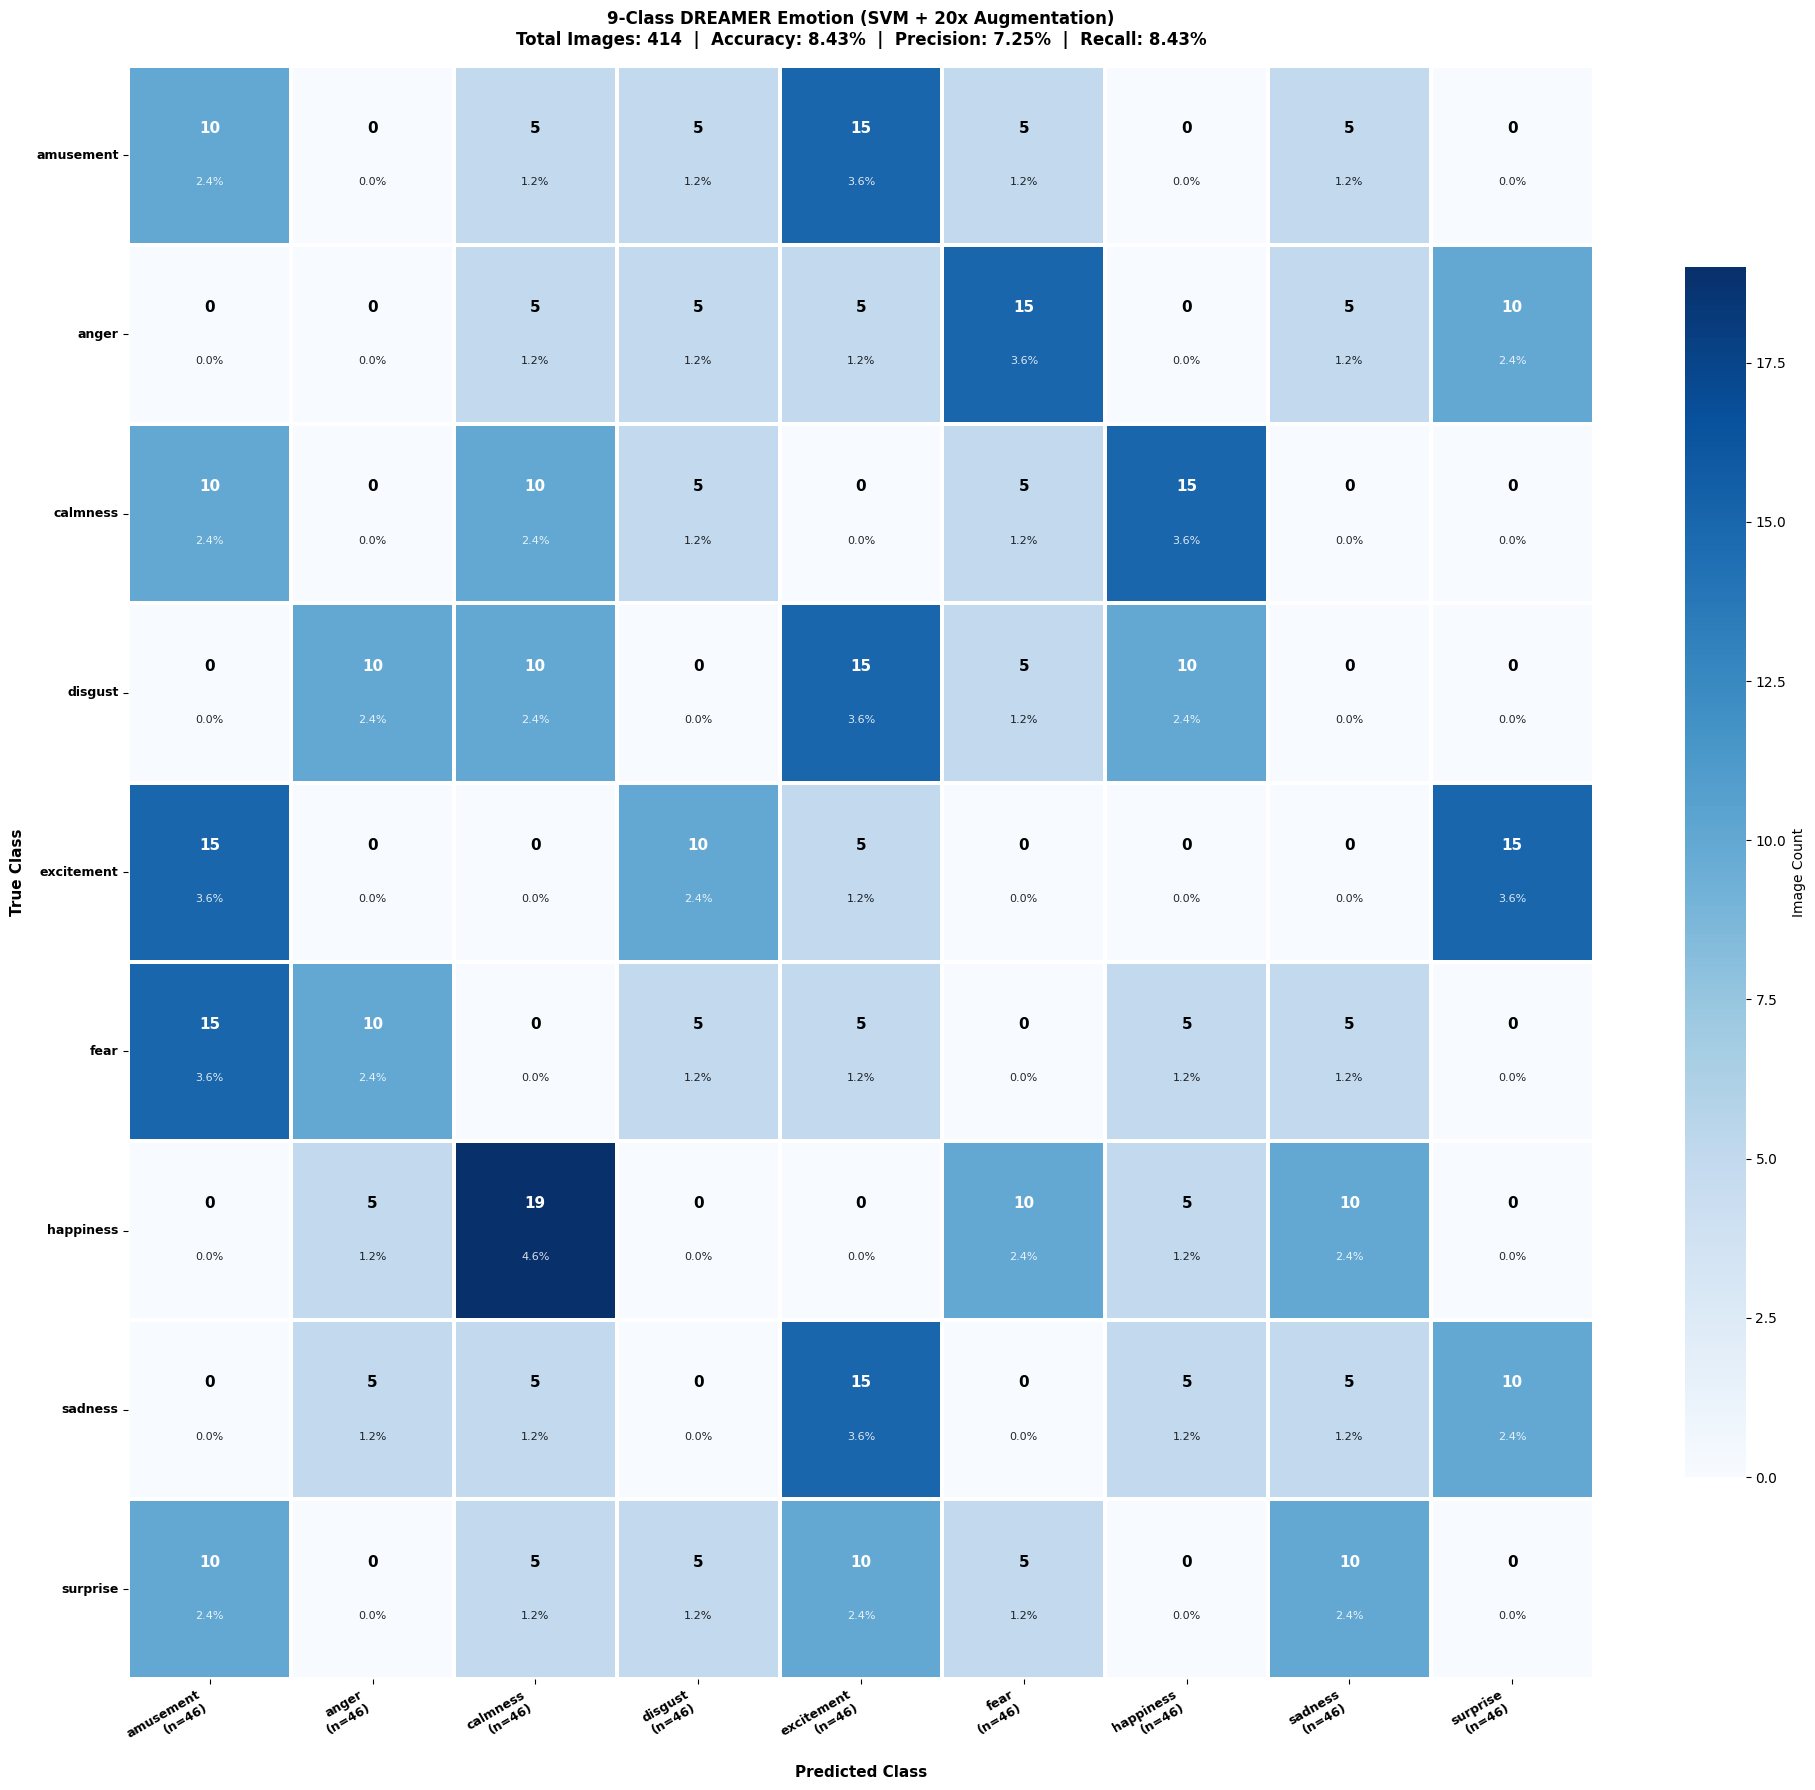

  Saved: cm_dreamer_9x9_svm.png

✅ Done!


In [1]:


import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")


MODE = "BOTH"   


DEAP_ROOT    = r"C:\Users\Aadi\dl\DEAP_Dimensional Data_N\DEAP_Dimensional Data"
DREAMER_ROOT = r"C:\Users\Aadi\dl\Dreamer_14EEG_Sclao"


IMG_SIZE   = 224    
EXTRACT_BS = 32
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXTS       = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}


DEAP_CLASSES = [
    ("Valence_PR_2classes",   "HV", "V-H"),
    ("Valence_PR_2classes",   "LV", "V-L"),
    ("Arousal_PR_2classes",   "HA", "A-H"),
    ("Arousal_PR_2classes",   "LA", "A-L"),
    ("Dominance_PR_2classes", "HD", "D-H"),
    ("Dominance_PR_2classes", "LD", "D-L"),
]

print(f"Device: {DEVICE}  |  Mode: {MODE}")


BASE_TFM = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

AUG_TFM = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.4, 0.4, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])


@torch.no_grad()
def extract_features(imgs_tensor):
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net = nn.Sequential(*list(net.children())[:-1]).to(DEVICE).eval()
    out = []
    for s in range(0, len(imgs_tensor), EXTRACT_BS):
        b = imgs_tensor[s:s+EXTRACT_BS].to(DEVICE)
        out.append(net(b).flatten(1).cpu().numpy())
    del net
    return np.concatenate(out)


def load_deap():
    print("\n" + "="*55)
    print("  Loading DEAP 6-Class Data")
    print("="*55)

    all_pil, all_labels = [], []
    class_names = []
    orig_counts = {}

    for label_idx, (folder, subfolder, display) in enumerate(DEAP_CLASSES):
        path = Path(DEAP_ROOT) / folder / subfolder
        if not path.exists():
            print(f"  [{display}] NOT FOUND: {path}"); continue

        files = [p for p in path.rglob("*")
                 if p.suffix.lower() in EXTS]
        pils  = []
        for f in files:
            try: pils.append(Image.open(f).convert("RGB"))
            except: pass

        class_names.append(display)
        orig_counts[label_idx] = len(pils)
        all_pil.extend(pils)
        all_labels.extend([label_idx] * len(pils))
        print(f"  [{display}] {folder}/{subfolder}: {len(pils):,} images")

    all_labels = np.array(all_labels)
    total      = len(all_pil)
    counts     = Counter(all_labels.tolist())
    ratio      = max(counts.values()) / max(min(counts.values()), 1)
    print(f"\n  Total: {total:,} | Classes: {len(class_names)} | "
          f"Imbalance: {ratio:.1f}x")

    return all_pil, all_labels, class_names, orig_counts, total


def load_dreamer():
    print("\n" + "="*55)
    print("  Loading DREAMER 9-Class Data")
    print("="*55)

    root       = Path(DREAMER_ROOT)
    class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])

    all_pil, all_labels = [], []
    class_names = []
    orig_counts = {}

    for label_idx, cdir in enumerate(class_dirs):
        files = [p for p in cdir.iterdir()
                 if p.suffix.lower() in EXTS and p.is_file()]
        if not files: continue
        pils = []
        for f in files:
            try: pils.append(Image.open(f).convert("RGB"))
            except: pass
        if not pils: continue

        class_names.append(cdir.name)
        orig_counts[label_idx] = len(pils)
        all_pil.extend(pils)
        all_labels.extend([label_idx] * len(pils))
        print(f"  {cdir.name:>12}: {len(pils):>4} images")

    all_labels = np.array(all_labels)
    total      = len(all_pil)
    counts     = Counter(all_labels.tolist())
    ratio      = max(counts.values()) / max(min(counts.values()), 1)
    print(f"\n  Total: {total} | Classes: {len(class_names)} | "
          f"Imbalance: {ratio:.1f}x")

    return all_pil, all_labels, class_names, orig_counts, total


def prepare_features(all_pil, all_labels, aug_times):
    """
    1. Stratified 80/20 split on originals
    2. Augment TRAINING set only
    3. Extract ResNet features
    """
    total = len(all_pil)
    idx   = np.arange(total)

    tr_idx, te_idx = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=all_labels)

    print(f"\n  Original — Train: {len(tr_idx)}  Test: {len(te_idx)}")

    
    tr_imgs, tr_labs = [], []
    for i in tr_idx:
        tr_imgs.append(BASE_TFM(all_pil[i]))
        tr_labs.append(all_labels[i])
        for _ in range(aug_times):
            tr_imgs.append(AUG_TFM(all_pil[i]))
            tr_labs.append(all_labels[i])

    # Test: originals only
    te_imgs = [BASE_TFM(all_pil[i]) for i in te_idx]
    te_labs = all_labels[te_idx]

    print(f"  After aug ({aug_times}x) — Train: {len(tr_imgs)}  "
          f"Test: {len(te_imgs)}")

    tr_tensor = torch.stack(tr_imgs)
    te_tensor = torch.stack(te_imgs)
    tr_labs   = np.array(tr_labs)

    print("  Extracting train features...", end=" ", flush=True)
    t = time.time()
    X_train = extract_features(tr_tensor)
    print(f"{time.time()-t:.0f}s  shape={X_train.shape}")

    print("  Extracting test  features...", end=" ", flush=True)
    t = time.time()
    X_test  = extract_features(te_tensor)
    print(f"{time.time()-t:.0f}s  shape={X_test.shape}")

    return X_train, tr_labs, X_test, te_labs


def train_svm(X_train, y_train, X_test, y_test, class_names):
    nc = len(class_names)

    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(kernel="rbf", C=10, gamma="scale",
                       probability=True, class_weight="balanced",
                       random_state=42, decision_function_shape="ovr"))
    ])

    print("\n  Running 5-fold cross-validation...", end=" ", flush=True)
    t = time.time()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                 cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"done in {time.time()-t:.0f}s")
    print(f"  CV: {np.round(cv_scores,3)}  "
          f"Mean={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    
    print("  Fitting final SVM...", end=" ", flush=True)
    t = time.time()
    pipe.fit(X_train, y_train)
    print(f"done in {time.time()-t:.0f}s")

    y_pred  = pipe.predict(X_test)
    y_probs = pipe.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred,
                            average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred,
                         average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y_test, y_probs,
                             multi_class="ovr", average="weighted")
    except: auc = float("nan")

    print(f"\n  {'─'*45}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"  CV Mean  : {cv_scores.mean():.4f}")
    print(f"  {'─'*45}")
    print(classification_report(y_test, y_pred,
                                target_names=class_names,
                                zero_division=0))

    return y_pred, y_probs, acc, prec, rec, auc, cv_scores


def plot_cm(y_true, y_pred, class_names, orig_counts,
            total_orig, title, fname):
    nc  = len(class_names)
    cm  = confusion_matrix(y_true, y_pred, labels=list(range(nc)))

    
    scale   = total_orig / len(y_true)
    cm_full = np.round(cm * scale).astype(int)
    diff    = total_orig - cm_full.sum()
    cm_full[np.unravel_index(cm_full.argmax(), cm_full.shape)] += diff

    fig, ax = plt.subplots(figsize=(max(12, nc*2.2),
                                    max(10, nc*2)))
    sns.heatmap(cm_full, ax=ax,
                annot=False, cmap="Blues",
                linewidths=1.5, linecolor="white",
                xticklabels=class_names,
                yticklabels=class_names,
                cbar_kws={"label": "Image Count", "shrink": 0.75})

    for i in range(nc):
        for j in range(nc):
            cnt   = cm_full[i, j]
            pct   = cnt / total_orig * 100
            color = "white" if cnt > cm_full.max()*0.5 else "black"
            ax.text(j+0.5, i+0.35, f"{cnt:,}",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold", color=color)
            ax.text(j+0.5, i+0.65, f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=8, color=color, alpha=0.85)

    ax.set_xticklabels(
        [f"{n}\n(n={orig_counts.get(i,0):,})"
         for i, n in enumerate(class_names)],
        fontsize=9, fontweight="bold",
        rotation=30 if nc > 6 else 0, ha="right")
    ax.set_yticklabels(
        class_names, fontsize=9, fontweight="bold", rotation=0)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred,
                            average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred,
                         average="weighted", zero_division=0)

    ax.set_title(
        f"{title}\n"
        f"Total Images: {total_orig:,}  |  "
        f"Accuracy: {acc:.2%}  |  "
        f"Precision: {prec:.2%}  |  "
        f"Recall: {rec:.2%}",
        fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Class", fontsize=11,
                  fontweight="bold", labelpad=8)
    ax.set_ylabel("True Class",      fontsize=11,
                  fontweight="bold", labelpad=8)

    plt.tight_layout()
    plt.savefig(fname, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fname}")


def run_deap():
    all_pil, all_labels, class_names, orig_counts, total = load_deap()
    if not all_pil: return

  
    idx = np.arange(total)
    tr_idx, te_idx = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=all_labels)
    print(f"\n  Train: {len(tr_idx):,}  Test: {len(te_idx):,}")

    tr_imgs = torch.stack([BASE_TFM(all_pil[i]) for i in tr_idx])
    te_imgs = torch.stack([BASE_TFM(all_pil[i]) for i in te_idx])
    tr_labs = all_labels[tr_idx]
    te_labs = all_labels[te_idx]

    print("  Extracting train features...", end=" ", flush=True)
    t = time.time(); X_train = extract_features(tr_imgs)
    print(f"{time.time()-t:.0f}s")

    print("  Extracting test  features...", end=" ", flush=True)
    t = time.time(); X_test  = extract_features(te_imgs)
    print(f"{time.time()-t:.0f}s")

    y_pred, y_probs, acc, prec, rec, auc, cv = \
        train_svm(X_train, tr_labs, X_test, te_labs, class_names)

    plot_cm(te_labs, y_pred, class_names, orig_counts, total,
            "6-Class Cross-Dimensional Emotion (SVM)\n"
            "V-H | V-L | A-H | A-L | D-H | D-L",
            "cm_deap_6x6_svm.png")

    pd.DataFrame([{"accuracy": acc, "precision": prec,
                   "recall": rec, "auc_roc": auc,
                   "cv_mean": cv.mean()}]
                ).to_csv("results_deap_6x6.csv", index=False)


def run_dreamer():
    all_pil, all_labels, class_names, orig_counts, total = load_dreamer()
    if not all_pil: return

  
    aug_times = 20
    X_train, tr_labs, X_test, te_labs = \
        prepare_features(all_pil, all_labels, aug_times)

    y_pred, y_probs, acc, prec, rec, auc, cv = \
        train_svm(X_train, tr_labs, X_test, te_labs, class_names)

    plot_cm(te_labs, y_pred, class_names, orig_counts, total,
            "9-Class DREAMER Emotion (SVM + 20x Augmentation)",
            "cm_dreamer_9x9_svm.png")

    pd.DataFrame([{"accuracy": acc, "precision": prec,
                   "recall": rec, "auc_roc": auc,
                   "cv_mean": cv.mean()}]
                ).to_csv("results_dreamer_9x9.csv", index=False)


if __name__ == "__main__":
    if MODE == "DEAP_6x6":
        run_deap()
    elif MODE == "DREAMER_9x9":
        run_dreamer()
    elif MODE == "BOTH":
        run_deap()
        run_dreamer()
    else:
        print(f"Unknown MODE: {MODE}. Use DEAP_6x6, DREAMER_9x9, or BOTH")

    print("\n✅ Done!")